# **Vishing Detection Using Machine Learning**

# **Import All Library**

In [1]:
import os
import random
import re
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import joblib

from IPython.display import Markdown, display
from scipy.sparse import vstack, issparse

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction import text
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import RFE, SelectKBest, chi2
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
)
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

from tensorflow.keras.layers import (
    Conv1D,
    Dense,
    Dropout,
    Embedding,
    GlobalMaxPooling1D,
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer


# --- Random Config ---
RANDOM_STATE = 24
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

In [2]:
def _to_1d_labels(y):
    y = np.asarray(y).reshape(-1)
    # If float probs and not already {0,1}
    if y.dtype.kind == "f":
        uniq = set(np.unique(y))
        if not uniq.issubset({0.0, 1.0}):
            y = (y >= 0.5).astype(int)
    return y.astype(int)

def plot_cm_like_example(y_true, y_pred, title, labels=("Non-scam", "Scam")):
    y_true = _to_1d_labels(y_true)
    y_pred = _to_1d_labels(y_pred)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])  # 0=Non-scam, 1=Scam

    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)

    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

    plt.colorbar(im, ax=ax)

    thresh = cm.max() / 2.0 if cm.max() > 0 else 0
    for i in range(2):
        for j in range(2):
            ax.text(
                j, i, f"{cm[i, j]}",
                ha="center", va="center",
                color="black",
                fontsize=12
            )

    fig.tight_layout()
    plt.show()

def confusion_by_type_2x2(y_true, y_pred, test_df_with_type,
                          types=("Support", "Reward", "Refund", "SSN"),
                          model_name="MODEL",
                          labels=("Non-scam", "Scam")):
    y_true = _to_1d_labels(y_true)
    y_pred = _to_1d_labels(y_pred)

    df = test_df_with_type.reset_index(drop=True).copy()
    if "category_4" not in df.columns:
        raise ValueError("test_df_with_type must contain column 'category_4'")

    print("\n" + "=" * 90)
    print(f"{model_name} | Accuracy: {accuracy_score(y_true, y_pred) * 100:.2f}%")
    print("Per-type confusion matrices (plotted)")

    for t in types:
        idx = df["category_4"].astype(str).str.strip().eq(t)
        n = int(idx.sum())

        if n == 0:
            print(f"\n[{t}] -> 0 rows (skipped)")
            continue

        print(f"\n[{t}] (n={n})")
        plot_cm_like_example(
            y_true[idx],
            y_pred[idx],
            title=f"{model_name} - {t} Confusion Matrix (n={n})",
            labels=labels
        )

# **Load Dataset**

In [3]:
# Basic settings
RANDOM_STATE = 42
TEXT_COL = "message"

DATA_PATH = "dataset/real_life_scam_non_scam_dataset.csv"

In [4]:
def clean_text(text):
    text = str(text)
    text = text.replace("\n", " ")
    text = text.replace("\t", " ")
    text = re.sub(r"\s+", " ", text)
    return text.strip()

In [5]:
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Cannot find file: {DATA_PATH}")

df = pd.read_csv(DATA_PATH, low_memory=False)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nLabel distribution:")
print(df["label_name"].value_counts())

print("\nSource distribution:")
print(df["source_dataset"].value_counts())

display(df.head())


Dataset loaded successfully!
Shape: (105627, 5)

Columns:
['message', 'label', 'label_name', 'source_dataset', 'data_type']

Label distribution:
label_name
non-scam    57947
scam        47680
Name: count, dtype: int64

Source distribution:
source_dataset
meajor             104572
analysisdataset      1055
Name: count, dtype: int64


,message,label,label_name,source_dataset,data_type
0,"Update Meeting for Monday, [DATE] has been can...",0,non-scam,meajor,email
1,[ORGANIZATION] [ADDRESS] and [ORGANIZATION] re...,1,scam,meajor,email
2,DSJ - DOURO S JOAO MUSIC FEST - [DATE] 550 5.1...,1,scam,meajor,email
3,CHASE: Review an attempt to charge $928.65 Rep...,1,scam,analysisdataset,sms
4,"Yo! Hey ! ""During a daytime I usually take cla...",1,scam,meajor,email


# **Data Cleaning**

## Function

In [6]:
import re
import html

def clean_message(text):
    text = str(text).lower()
    text = html.unescape(text)

    # Remove old synthetic leakage if it exists
    text = re.sub(
        r"\breference\s*:\s*\[(case|ref)_\d+\]\s*\.?",
        " ",
        text,
        flags=re.IGNORECASE
    )

    # Remove letter id leakage
    text = re.sub(
        r"\[letter id:\s*\[reference_number\]\]",
        " ",
        text,
        flags=re.IGNORECASE
    )

    # Convert real URLs into normal token
    text = re.sub(
        r"http\S+|www\.\S+",
        " url ",
        text,
        flags=re.IGNORECASE
    )

    # Convert email addresses into normal token
    text = re.sub(
        r"\b[\w\.-]+@[\w\.-]+\.\w+\b",
        " email ",
        text,
        flags=re.IGNORECASE
    )

    # Convert phone-like numbers into normal token
    text = re.sub(
        r"\b(?:\+?\d[\d\s\-()]{6,}\d)\b",
        " phone ",
        text
    )

    # Handle <|URL|>, <|EMAIL|>, <|PHONE|>, <|FILE|>, etc.
    def replace_angle_token(match):
        token = match.group(1).lower()
        token = token.replace("simbol", "symbol")

        if "url" in token:
            return " url "
        elif "email" in token:
            return " email "
        elif "phone" in token:
            return " phone "
        elif "file" in token:
            return " file "
        elif "emoji" in token or "symbol" in token:
            return " "
        else:
            token = re.sub(r"[^a-z0-9]+", " ", token)
            return " " + token + " "

    text = re.sub(
        r"<\|([^|]+)\|>",
        replace_angle_token,
        text,
        flags=re.IGNORECASE
    )

    # Handle [REFERENCE_NUMBER], [NAME], [DATE], [[PRODUCT]], etc.
    def replace_square_token(match):
        token = match.group(1).lower()
        token = token.replace("_", " ")

        if token in ["fake link", "url"]:
            return " url "
        elif token in ["phone number", "phone"]:
            return " phone "
        elif token in ["email address", "email"]:
            return " email "
        elif token in ["reference number"]:
            return " number "
        elif token in ["date", "time", "location", "address"]:
            return " " + token + " "
        elif token in ["name", "organization", "product", "username"]:
            return " " + token + " "
        elif token in ["file name", "file path"]:
            return " file "
        else:
            return " " + token + " "

    text = re.sub(
        r"\[+\s*([a-zA-Z_ ]+)\s*\]+",
        replace_square_token,
        text,
        flags=re.IGNORECASE
    )

    # Remove wiki-style metadata noise like ///color/// or ///population_density///
    text = re.sub(
        r"///[a-zA-Z_]+///?",
        " ",
        text
    )

    # Normalize urgency time
    # Example: 24 hours, 48 hrs, 72 h -> time limit
    text = re.sub(
        r"\b(6|12|24|48|72)\s*(hours?|hrs?|h)\b",
        " time limit ",
        text,
        flags=re.IGNORECASE
    )

    # Normalize very long numbers only
    # Keeps useful short numbers like 365, but replaces random IDs
    text = re.sub(
        r"\b\d{4,}\b",
        " number ",
        text
    )

    # Remove punctuation/symbols but keep letters and numbers
    text = re.sub(
        r"[^a-zA-Z0-9\s]",
        " ",
        text
    )

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

## Cleaned message before and after

In [7]:
df["clean_message"] = df["message"].apply(clean_message)

# Show full column content
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

comparison_table = (
    df[["message", "clean_message"]]
    .head(5)
    .reset_index(drop=True)
)

comparison_table.index = comparison_table.index + 1

comparison_table = comparison_table.rename(columns={
    "message": "Original Message",
    "clean_message": "Cleaned Message"
})

display(comparison_table)

,Original Message,Cleaned Message
1,"Update Meeting for Monday, [DATE] has been cancelled. We will meet tomorrow morning in 16C1 at [TIME] If you have any questions, please contact me at [PHONE_NUMBER]. See you in the morning! [NAME]",update meeting for monday date has been cancelled we will meet tomorrow morning in 16c1 at time if you have any questions please contact me at phone see you in the morning name
2,"[ORGANIZATION] [ADDRESS] and [ORGANIZATION] renew their agreement. This week, we're telling you how to lower your [PRODUCT] costs while increasing your profit. Search engine news of the week [ORGANIZATION] releases [PRODUCT] search engine [ORGANIZATION] has just released a special search form for its AdWords ads. [ORGANIZATION] set to buy desktop search firm ""[ORGANIZATION]. Many people use [ORGANIZATION] to find web sites on the Internet. It was from a person who received the following answer to a PageRank question from a [ORGANIZATION] employee: ""The PageRank that is displayed in the [PRODUCT] is for entertainment purposes only. "" The magic that makes [ORGANIZATION] tick ""[ORGANIZATION] vice-president of engineering was in London this week to talk to potential recruits about just what lies behind that search page. How to fake [ORGANIZATION] PageRank numbers View all past issues. Just use [ORGANIZATION]mon sense. "" 2005: The Year for Desktop Search ""What [ORGANIZATION] knows that even the top of the heap of Web search engines do not is how to control loyalty on the desktop. For example, [PRODUCT] uses data about the overall popularity of various searches to help rank the refinements it offers. How does [ORGANIZATION] rank web pages? [ORGANIZATION] publishes a list of the most linked pages on the web. Announcement: How to optimize your [PRODUCT] campaigns [ORGANIZATION] AdWords are small text ads that appear next to the search results on [ORGANIZATION]. Make sure that your web pages are optimized for [ORGANIZATION]. Some CEOs surf Web to see how they're being portrayed. "" 2005: The Year for Desktop Search ""What [ORGANIZATION] knows that even the top of the heap of Web search engines do not is how to control loyalty on the desktop. is trying to establish an online reading room for five major libraries by scanning stacks of hard-to-find books into its widely used Internet search engine. Back to table of contents - Visit Axandra. Could visitors of the other web site be interested in your site? Further information about [ORGANIZATION] library project. "" [ORGANIZATION] launching second act with e-mail client ""With the launch of the [PRODUCT]. If you like a page, changes are that other people also like that page, no matter what PageRank the [ORGANIZATION] toolbar displays. Take a look at the top searches on [ORGANIZATION] in 2004. Lower your advertising costs and make more profit! He said that toolbar users use the PageRank display to judge the quality of web pages. Last week, two statements about [ORGANIZATION] PageRank started a new discussion about this topic. Though the 500 so-called second-tier search engines garner as little as 2 percent of the search market share, they offer something [ORGANIZATION] and [ORGANIZATION] increasingly do not: low-priced leads. Back to table of contents - Visit Axandra. Some people talk about their job interviews at [ORGANIZATION]. Articles of the week Accoona: Should [ORGANIZATION] worry? This 150-page eBook tells you how to find affordable keywords, how to write successful ads and how to increase the effectiveness of your AdWords ads. Just enter a keyword or phrase, and [PRODUCT] will quickly retrieve any file or email on your hard drive matching your query. ] Here is a roundup of some of the questions asked and answers posited. What are their navigation habits? "" Search engine newslets U. [ADDRESS] has enhanced its range of financial services ""The Internet portal [ORGANIZATION] However, the PageRank number that is displayed in the [PRODUCT] and the green PageRank bar are not 

## *TF-IDF VECTORIZATION for counting similarity*

In [8]:
scam_df = df[df["label"] == 1].copy()
nonscam_df = df[df["label"] == 0].copy()

all_text = pd.concat(
    [scam_df["clean_message"], nonscam_df["clean_message"]],
    axis=0
).reset_index(drop=True)

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=3,
    max_features=10000,
    norm="l2"
)

X = vectorizer.fit_transform(all_text)

X_scam = X[:len(scam_df)]
X_nonscam = X[len(scam_df):]

# **Data Split**

In [9]:
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split


# ─────────────────────────────────────────────
# RANDOM CONFIG
# ─────────────────────────────────────────────

RANDOM_STATE = 24


# ─────────────────────────────────────────────
# PREPARE LABELS
# ─────────────────────────────────────────────

df.columns = [c.strip().lower() for c in df.columns]

# Convert labels to numeric:
# scam = 1, non-scam = 0
label_text = df["label"].astype(str).str.lower().str.strip()

label_map = {
    "scam": 1,
    "1": 1,
    "non-scam": 0,
    "nonscam": 0,
    "non scam": 0,
    "0": 0
}

df["label"] = label_text.map(label_map)

if df["label"].isna().any():
    print("Unknown labels found:")
    print(label_text[df["label"].isna()].unique())
    raise ValueError("Some labels could not be converted.")

df["label"] = df["label"].astype(int)

# Use clean_message if available, otherwise use message
TEXT_COL = "clean_message" if "clean_message" in df.columns else "message"

df[TEXT_COL] = df[TEXT_COL].astype(str).str.strip()
df = df[df[TEXT_COL] != ""].reset_index(drop=True)

print("Using text column:", TEXT_COL)
print("Dataset shape:", df.shape)
print(df["label"].value_counts().rename({1: "scam", 0: "non-scam"}))


# ─────────────────────────────────────────────
# SHUFFLE FUNCTION
# ─────────────────────────────────────────────

def shuffle_split_data(data, random_state=24):
    """
    Shuffle scam rows, shuffle non-scam rows,
    then combine and shuffle the full split.
    """

    scam_part = data[data["label"] == 1].sample(
        frac=1,
        random_state=random_state
    )

    nonscam_part = data[data["label"] == 0].sample(
        frac=1,
        random_state=random_state
    )

    shuffled_data = pd.concat(
        [scam_part, nonscam_part],
        ignore_index=True
    ).sample(
        frac=1,
        random_state=random_state
    ).reset_index(drop=True)

    return shuffled_data


# ─────────────────────────────────────────────
# SPLIT DATA: 80 / 10 / 10
# Pair-safe version
# ─────────────────────────────────────────────

if "pair_id" in df.columns:
    print("\nUsing pair_id-safe split.")

    unique_pairs = df["pair_id"].drop_duplicates()

    # 80% train, 20% temporary
    train_pairs, temp_pairs = train_test_split(
        unique_pairs,
        test_size=0.20,
        random_state=RANDOM_STATE,
        shuffle=True
    )

    # Split temporary into 10% validation and 10% test
    valid_pairs, test_pairs = train_test_split(
        temp_pairs,
        test_size=0.50,
        random_state=RANDOM_STATE,
        shuffle=True
    )

    train_data = df[df["pair_id"].isin(train_pairs)].reset_index(drop=True)
    valid_data = df[df["pair_id"].isin(valid_pairs)].reset_index(drop=True)
    test_data  = df[df["pair_id"].isin(test_pairs)].reset_index(drop=True)

    # Shuffle scam, shuffle non-scam, then mix
    train_data = shuffle_split_data(train_data, RANDOM_STATE)
    valid_data = shuffle_split_data(valid_data, RANDOM_STATE)
    test_data  = shuffle_split_data(test_data, RANDOM_STATE)

else:
    train_data, temp_data = train_test_split(
        df,
        test_size=0.20,
        stratify=df["label"],
        random_state=RANDOM_STATE,
        shuffle=True
    )

    valid_data, test_data = train_test_split(
        temp_data,
        test_size=0.50,
        stratify=temp_data["label"],
        random_state=RANDOM_STATE,
        shuffle=True
    )

    # Shuffle scam, shuffle non-scam, then mix
    train_data = shuffle_split_data(train_data, RANDOM_STATE)
    valid_data = shuffle_split_data(valid_data, RANDOM_STATE)
    test_data  = shuffle_split_data(test_data, RANDOM_STATE)


# ─────────────────────────────────────────────
# X / y
# ─────────────────────────────────────────────

X_train, y_train = train_data[TEXT_COL], train_data["label"]
X_valid, y_valid = valid_data[TEXT_COL], valid_data["label"]
X_test,  y_test  = test_data[TEXT_COL],  test_data["label"]


# ─────────────────────────────────────────────
# PRINT SPLIT DISTRIBUTION
# ─────────────────────────────────────────────

def print_split(name, data):
    scam_count = (data["label"] == 1).sum()
    nonscam_count = (data["label"] == 0).sum()

    print(
        f"{name}: {len(data):,}  "
        f"(scam={scam_count:,}, non-scam={nonscam_count:,})"
    )


print("\n80 / 10 / 10 Split Distribution")
print("==================")
print_split("Train", train_data)
print_split("Valid", valid_data)
print_split("Test ", test_data)


# ─────────────────────────────────────────────
# CHECK PAIR LEAKAGE
# ─────────────────────────────────────────────

if "pair_id" in df.columns:
    train_pair_set = set(train_data["pair_id"])
    valid_pair_set = set(valid_data["pair_id"])
    test_pair_set = set(test_data["pair_id"])

    leakage_train_valid = len(train_pair_set.intersection(valid_pair_set))
    leakage_train_test = len(train_pair_set.intersection(test_pair_set))
    leakage_valid_test = len(valid_pair_set.intersection(test_pair_set))

    print("\n80 / 10 / 10 Pair Leakage Check")
    print("==================")
    print("Train-Valid shared pair_id:", leakage_train_valid)
    print("Train-Test shared pair_id :", leakage_train_test)
    print("Valid-Test shared pair_id :", leakage_valid_test)

    if leakage_train_valid == 0 and leakage_train_test == 0 and leakage_valid_test == 0:
        print("No pair leakage detected.")
    else:
        print("Warning: pair leakage detected.")

# ─────────────────────────────────────────────
# ANOTHER SPLIT: 70 / 15 / 15
# Pair-safe version
# ─────────────────────────────────────────────

if "pair_id" in df.columns:
    print("\nUsing pair_id-safe split for 70/15/15.")

    unique_pairs = df["pair_id"].drop_duplicates()

    # 70% train, 30% temporary
    train_pairs_70, temp_pairs_30 = train_test_split(
        unique_pairs,
        test_size=0.30,
        random_state=RANDOM_STATE,
        shuffle=True
    )

    # Split temporary 30% into 15% validation and 15% test
    valid_pairs_15, test_pairs_15 = train_test_split(
        temp_pairs_30,
        test_size=0.50,
        random_state=RANDOM_STATE,
        shuffle=True
    )

    train_data_70 = df[df["pair_id"].isin(train_pairs_70)].reset_index(drop=True)
    valid_data_15 = df[df["pair_id"].isin(valid_pairs_15)].reset_index(drop=True)
    test_data_15  = df[df["pair_id"].isin(test_pairs_15)].reset_index(drop=True)

    # Shuffle scam, shuffle non-scam, then mix
    train_data_70 = shuffle_split_data(train_data_70, RANDOM_STATE)
    valid_data_15 = shuffle_split_data(valid_data_15, RANDOM_STATE)
    test_data_15  = shuffle_split_data(test_data_15, RANDOM_STATE)

else:

    train_data_70, temp_data_30 = train_test_split(
        df,
        test_size=0.30,
        stratify=df["label"],
        random_state=RANDOM_STATE,
        shuffle=True
    )

    valid_data_15, test_data_15 = train_test_split(
        temp_data_30,
        test_size=0.50,
        stratify=temp_data_30["label"],
        random_state=RANDOM_STATE,
        shuffle=True
    )

    train_data_70 = shuffle_split_data(train_data_70, RANDOM_STATE)
    valid_data_15 = shuffle_split_data(valid_data_15, RANDOM_STATE)
    test_data_15  = shuffle_split_data(test_data_15, RANDOM_STATE)


# ─────────────────────────────────────────────
# X / y for 70 / 15 / 15 split
# ─────────────────────────────────────────────

X_train_70, y_train_70 = train_data_70[TEXT_COL], train_data_70["label"]
X_valid_15, y_valid_15 = valid_data_15[TEXT_COL], valid_data_15["label"]
X_test_15,  y_test_15  = test_data_15[TEXT_COL],  test_data_15["label"]


# ─────────────────────────────────────────────
# PRINT 70 / 15 / 15 SPLIT DISTRIBUTION
# ─────────────────────────────────────────────

print("\n70 / 15 / 15 Split Distribution")
print("===============================")
print_split("Train 70%", train_data_70)
print_split("Valid 15%", valid_data_15)
print_split("Test  15%", test_data_15)


# ─────────────────────────────────────────────
# CHECK PAIR LEAKAGE FOR 70 / 15 / 15
# ─────────────────────────────────────────────

if "pair_id" in df.columns:
    train_pair_set_70 = set(train_data_70["pair_id"])
    valid_pair_set_15 = set(valid_data_15["pair_id"])
    test_pair_set_15  = set(test_data_15["pair_id"])

    leakage_train_valid_70 = len(train_pair_set_70.intersection(valid_pair_set_15))
    leakage_train_test_70  = len(train_pair_set_70.intersection(test_pair_set_15))
    leakage_valid_test_70  = len(valid_pair_set_15.intersection(test_pair_set_15))

    print("\nPair Leakage Check for 70 / 15 / 15")
    print("===================================")
    print("Train-Valid shared pair_id:", leakage_train_valid_70)
    print("Train-Test shared pair_id :", leakage_train_test_70)
    print("Valid-Test shared pair_id :", leakage_valid_test_70)

    if leakage_train_valid_70 == 0 and leakage_train_test_70 == 0 and leakage_valid_test_70 == 0:
        print("No pair leakage detected.")
    else:
        print("Warning: pair leakage detected.")






Using text column: clean_message
Dataset shape: (105601, 6)
label
non-scam    57947
scam        47654
Name: count, dtype: int64

80 / 10 / 10 Split Distribution
Train: 84,480  (scam=38,123, non-scam=46,357)
Valid: 10,560  (scam=4,765, non-scam=5,795)
Test : 10,561  (scam=4,766, non-scam=5,795)

70 / 15 / 15 Split Distribution
Train 70%: 73,920  (scam=33,357, non-scam=40,563)
Valid 15%: 15,840  (scam=7,148, non-scam=8,692)
Test  15%: 15,841  (scam=7,149, non-scam=8,692)


# Dataset Split Variables

## 80 / 10 / 10 Split

| Dataset Part | Features Variable | Label Variable | Purpose |
|---|---|---|---|
| Training Set | `X_train` | `y_train` | Used to train the model |
| Validation Set | `X_valid` | `y_valid` | Not used |
| Test Set | `X_test` | `y_test` | Used for final evaluation |

---

## 70 / 15 / 15 Split

| Dataset Part | Features Variable | Label Variable | Purpose |
|---|---|---|---|
| Training Set | `X_train_70` | `y_train_70` | Used to train the model |
| Validation Set | `X_valid_15` | `y_valid_15` | Not used |
| Test Set | `X_test_15` | `y_test_15` | Used for final evaluation |

---

## Split Comparison

| Split Ratio | Training | Validation | Testing |
|---|---:|---:|---:|
| 80 / 10 / 10 | 80% | 10% | 10% |
| 70 / 15 / 15 | 70% | 15% | 15% |

**Note:**  
The 80/10/10 split gives more data for training.  
The 70/15/15 split gives more data for validation and testing.

# **Random Search**

Using text column: message
SMOTE: True
RF random configs: 8
SVM random configs: 8
Output folder: results

Random Search Size
RF configs : 8
SVM configs: 8
Splits     : 2
Folds      : 3
Total CV fold runs: 96

Resume check
Completed configs found: 0
Total random-search jobs: 32
Random Search |██████████████████████████████| 32/32 (100.0%) CV Macro F1=0.9123 ETA=0.0minn

Random search completed.
Results saved to: results\random_results_live.csv
Fold results saved to: results\random_fold_results_live.csv
Best summary saved to: results\random_best_summary_live.csv


════════════════════════════════════════════════════════════════════════════════
BEST RANDOM SEARCH CONFIGURATION PER SPLIT × MODEL
Ranked by CV Macro F1
════════════════════════════════════════════════════════════════════════════════


,split,model,config_id,tfidf_max_features,tfidf_min_df,tfidf_ngram_range,chi2_k,rfe_n_features,clf_n_estimators,clf_max_depth,clf_min_samples_split,clf_min_samples_leaf,clf_C,clf_kernel,cv_f1_macro_mean,cv_f1_macro_std,cv_scam_recall_mean,test_accuracy,test_f1_macro,test_scam_recall
0,80/10/10,RandomForest,8,1200,5,"(1, 2)",1200,400,200.000000,30.000000,10.000000,1.000000,nan,None,0.9623,0.0029,0.9546,0.9634,0.9630,0.9585
1,70/15/15,RandomForest,8,1200,5,"(1, 2)",1200,400,200.000000,30.000000,10.000000,1.000000,nan,None,0.9606,0.0005,0.9545,0.9612,0.9608,0.9543
2,80/10/10,SVM,5,2500,5,"(1, 2)",700,400,nan,nan,nan,nan,0.300000,linear,0.9400,0.0029,0.9436,0.9389,0.9384,0.9400
3,70/15/15,SVM,5,2500,5,"(1, 2)",700,400,nan,nan,nan,nan,0.300000,linear,0.9397,0.0024,0.9424,0.9368,0.9362,0.9361



🏆 Overall Best Random Search Configuration
Split: 80/10/10
Model: RandomForest
Config ID: 8
CV Macro F1: 0.9623
Test Macro F1: 0.963
Test Scam Recall: 0.9585


════════════════════════════════════════════════════════════════════════════════
DETAILED CLASSIFICATION REPORTS FOR BEST RANDOM SEARCH CONFIGS
════════════════════════════════════════════════════════════════════════════════

── 80/10/10 | RandomForest | Config 8 ──
              precision    recall  f1-score   support

    Non-Scam     0.9659    0.9674    0.9666      5795
        Scam     0.9603    0.9585    0.9594      4768

    accuracy                         0.9634     10563
   macro avg     0.9631    0.9629    0.9630     10563
weighted avg     0.9634    0.9634    0.9634     10563



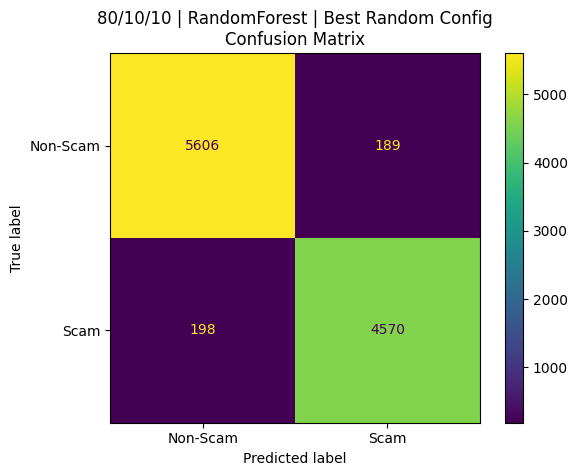


── 70/15/15 | RandomForest | Config 8 ──
              precision    recall  f1-score   support

    Non-Scam     0.9626    0.9669    0.9647      8693
        Scam     0.9595    0.9543    0.9569      7152

    accuracy                         0.9612     15845
   macro avg     0.9610    0.9606    0.9608     15845
weighted avg     0.9612    0.9612    0.9612     15845



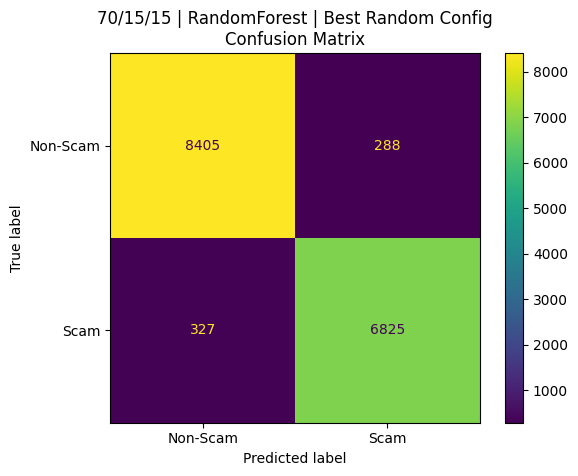


── 80/10/10 | SVM | Config 5 ──
              precision    recall  f1-score   support

    Non-Scam     0.9500    0.9381    0.9440      5795
        Scam     0.9258    0.9400    0.9329      4768

    accuracy                         0.9389     10563
   macro avg     0.9379    0.9390    0.9384     10563
weighted avg     0.9391    0.9389    0.9390     10563



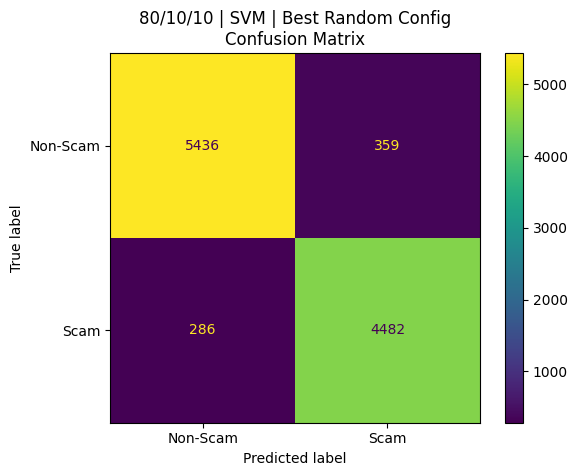


── 70/15/15 | SVM | Config 5 ──
              precision    recall  f1-score   support

    Non-Scam     0.9469    0.9373    0.9421      8693
        Scam     0.9247    0.9361    0.9304      7152

    accuracy                         0.9368     15845
   macro avg     0.9358    0.9367    0.9362     15845
weighted avg     0.9369    0.9368    0.9368     15845



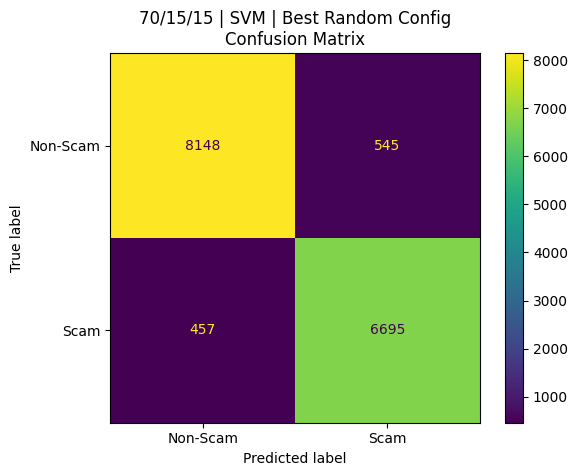

In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# RANDOM SEARCH + 3-FOLD CV + SMOTE + AUTO-SAVE CHECKPOINTS
#
# Saves:
#   results/random_fold_results_live.csv
#   results/random_results_live.csv
#   results/random_best_summary_live.csv
#   results/random_errors.csv
# ═══════════════════════════════════════════════════════════════════════════════

import os
import time
import json
import traceback
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.feature_extraction import text as sktext
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2, RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold, ParameterSampler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from imblearn.over_sampling import SMOTE
from collections import Counter


# ═══════════════════════════════════════════════════════════════════════════════
# BASIC CONFIG
# ═══════════════════════════════════════════════════════════════════════════════

RANDOM_STATE = 24
N_FOLDS = 3
USE_SMOTE = True

# Random search amount
# Increase this later if you want better tuning.
N_ITER_RF = 8
N_ITER_SVM = 8

OUTPUT_DIR = "results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

RESULTS_PATH = os.path.join(OUTPUT_DIR, "random_results_live.csv")
FOLD_RESULTS_PATH = os.path.join(OUTPUT_DIR, "random_fold_results_live.csv")
BEST_SUMMARY_PATH = os.path.join(OUTPUT_DIR, "random_best_summary_live.csv")
ERROR_LOG_PATH = os.path.join(OUTPUT_DIR, "random_errors.csv")

# Use clean_message if available, otherwise use message
TEXT_COL = "clean_message" if "clean_message" in train_data.columns else "message"

print("Using text column:", TEXT_COL)
print("SMOTE:", USE_SMOTE)
print("RF random configs:", N_ITER_RF)
print("SVM random configs:", N_ITER_SVM)
print("Output folder:", OUTPUT_DIR)


# ═══════════════════════════════════════════════════════════════════════════════
# SPLITS
# ═══════════════════════════════════════════════════════════════════════════════

SPLITS = {
    "80/10/10": {
        "train": train_data,
        "test": test_data
    },
    "70/15/15": {
        "train": train_data_70,
        "test": test_data_15
    },
}


# ═══════════════════════════════════════════════════════════════════════════════
# SAVE HELPERS
# ═══════════════════════════════════════════════════════════════════════════════

def append_row_csv(row, path):
    row_df = pd.DataFrame([row])
    file_exists = os.path.exists(path)

    row_df.to_csv(
        path,
        mode="a",
        header=not file_exists,
        index=False
    )


def load_completed_configs(path):
    if not os.path.exists(path):
        return set()

    old = pd.read_csv(path)

    required_cols = {"split", "model", "config_id"}

    if not required_cols.issubset(old.columns):
        return set()

    completed = set(
        zip(
            old["split"].astype(str),
            old["model"].astype(str),
            old["config_id"].astype(int)
        )
    )

    return completed


def update_best_summary():
    if not os.path.exists(RESULTS_PATH):
        return

    df_live = pd.read_csv(RESULTS_PATH)

    if len(df_live) == 0:
        return

    summary = (
        df_live
        .sort_values("cv_f1_macro_mean", ascending=False)
        .groupby(["split", "model"], sort=False)
        .first()
        .reset_index()
        .sort_values("cv_f1_macro_mean", ascending=False)
        .reset_index(drop=True)
    )

    summary.to_csv(BEST_SUMMARY_PATH, index=False)


# ═══════════════════════════════════════════════════════════════════════════════
# CONFUSION MATRIX FUNCTION
# ═══════════════════════════════════════════════════════════════════════════════

def plot_cm_like_example(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Non-Scam", "Scam"]
    )

    disp.plot(values_format="d")
    plt.title(title)
    plt.show()


# ═══════════════════════════════════════════════════════════════════════════════
# STOP WORDS
# ═══════════════════════════════════════════════════════════════════════════════

my_stop_words = list(sktext.ENGLISH_STOP_WORDS) + ["placeholder"]


# ═══════════════════════════════════════════════════════════════════════════════
# RANDOM SEARCH PARAMETER DISTRIBUTIONS
# ═══════════════════════════════════════════════════════════════════════════════

RF_PARAM_DIST = {
    # TF-IDF
    "tfidf_max_features": [1200, 1500, 2000, 2500, 3000],
    "tfidf_min_df": [3, 5],
    "tfidf_ngram_range": [(1, 2)],
    "tfidf_sublinear_tf": [True],

    # Feature selection
    "chi2_k": [500, 700, 900, 1200],
    "rfe_n_features": [150, 300, 400],

    # Random Forest
    "clf_n_estimators": [100, 150, 200],
    "clf_max_depth": [15, 20, 30, None],
    "clf_min_samples_split": [2, 5, 10],
    "clf_min_samples_leaf": [1, 3, 5],
    "clf_max_features": ["sqrt"],
    "clf_class_weight": [None],
    "clf_bootstrap": [True],
}


SVM_PARAM_DIST = {
    # TF-IDF
    "tfidf_max_features": [1200, 1500, 2000, 2500, 3000],
    "tfidf_min_df": [3, 5],
    "tfidf_ngram_range": [(1, 2)],
    "tfidf_sublinear_tf": [True],

    # Feature selection
    "chi2_k": [500, 700, 900, 1200],
    "rfe_n_features": [150, 200, 300, 400],

    # SVM
    "clf_C": [0.1, 0.2, 0.3, 0.5, 1.0],
    "clf_kernel": ["linear"],
    "clf_gamma": ["scale"],
    "clf_class_weight": [None],
}


RF_RANDOM_CONFIGS = list(ParameterSampler(
    RF_PARAM_DIST,
    n_iter=N_ITER_RF,
    random_state=RANDOM_STATE
))

SVM_RANDOM_CONFIGS = list(ParameterSampler(
    SVM_PARAM_DIST,
    n_iter=N_ITER_SVM,
    random_state=RANDOM_STATE + 1
))

print("\nRandom Search Size")
print("==================")
print("RF configs :", len(RF_RANDOM_CONFIGS))
print("SVM configs:", len(SVM_RANDOM_CONFIGS))
print("Splits     :", len(SPLITS))
print("Folds      :", N_FOLDS)

total_cv_runs = (len(RF_RANDOM_CONFIGS) + len(SVM_RANDOM_CONFIGS)) * len(SPLITS) * N_FOLDS
print("Total CV fold runs:", total_cv_runs)


# ═══════════════════════════════════════════════════════════════════════════════
# METRIC HELPER
# ═══════════════════════════════════════════════════════════════════════════════

def compute_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),

        "precision_weighted": precision_score(
            y_true, y_pred,
            average="weighted",
            zero_division=0
        ),

        "recall_weighted": recall_score(
            y_true, y_pred,
            average="weighted",
            zero_division=0
        ),

        "f1_weighted": f1_score(
            y_true, y_pred,
            average="weighted",
            zero_division=0
        ),

        "precision_macro": precision_score(
            y_true, y_pred,
            average="macro",
            zero_division=0
        ),

        "recall_macro": recall_score(
            y_true, y_pred,
            average="macro",
            zero_division=0
        ),

        "f1_macro": f1_score(
            y_true, y_pred,
            average="macro",
            zero_division=0
        ),

        "scam_recall": recall_score(
            y_true, y_pred,
            pos_label=1,
            zero_division=0
        ),

        "nonscam_recall": recall_score(
            y_true, y_pred,
            pos_label=0,
            zero_division=0
        ),
    }


# ═══════════════════════════════════════════════════════════════════════════════
# PIPELINE
# TF-IDF → Variance Filter → Chi² → RFE → SMOTE → Classifier
# ═══════════════════════════════════════════════════════════════════════════════

def run_pipeline(X_tr_raw, y_tr, X_te_raw, y_te, params, model_type):
    """
    Fit everything on training data only.
    Apply SMOTE only after feature selection and only to training features.
    """

    # ── TF-IDF ───────────────────────────────────────────────────────────────
    tfidf = TfidfVectorizer(
        max_features=params["tfidf_max_features"],
        min_df=params["tfidf_min_df"],
        ngram_range=params["tfidf_ngram_range"],
        sublinear_tf=params["tfidf_sublinear_tf"],
        stop_words=my_stop_words,
    )

    X_tr_tfidf = tfidf.fit_transform(X_tr_raw.astype(str))
    X_te_tfidf = tfidf.transform(X_te_raw.astype(str))

    # ── Variance filter ─────────────────────────────────────────────────────
    col_means = np.asarray(X_tr_tfidf.mean(axis=0)).ravel()
    var_mask = col_means > 0

    X_tr_var = X_tr_tfidf[:, var_mask]
    X_te_var = X_te_tfidf[:, var_mask]

    # ── Chi-square ──────────────────────────────────────────────────────────
    k_chi2 = min(params["chi2_k"], X_tr_var.shape[1])

    chi2_sel = SelectKBest(
        score_func=chi2,
        k=k_chi2
    )

    X_tr_chi = chi2_sel.fit_transform(X_tr_var, y_tr)
    X_te_chi = chi2_sel.transform(X_te_var)

    # ── RFE ─────────────────────────────────────────────────────────────────
    k_rfe = min(params["rfe_n_features"], X_tr_chi.shape[1])

    rfe_est = RandomForestClassifier(
        n_estimators=30,
        max_depth=15,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    rfe_sel = RFE(
        estimator=rfe_est,
        n_features_to_select=k_rfe,
        step=0.1
    )

    rfe_sel.fit(X_tr_chi, y_tr)

    X_tr_rfe = rfe_sel.transform(X_tr_chi)
    X_te_rfe = rfe_sel.transform(X_te_chi)

    # Convert to dense after RFE because SMOTE works better with dense arrays.
    if hasattr(X_tr_rfe, "toarray"):
        X_tr_rfe = X_tr_rfe.toarray()

    if hasattr(X_te_rfe, "toarray"):
        X_te_rfe = X_te_rfe.toarray()

    # ── SMOTE on training only ──────────────────────────────────────────────
    before_smote = dict(Counter(y_tr))

    if USE_SMOTE:
        minority_count = min(Counter(y_tr).values())

        if minority_count > 1:
            k_neighbors = min(5, minority_count - 1)

            smote = SMOTE(
                random_state=RANDOM_STATE,
                k_neighbors=k_neighbors
            )

            X_tr_final, y_tr_final = smote.fit_resample(X_tr_rfe, y_tr)
        else:
            X_tr_final, y_tr_final = X_tr_rfe, y_tr
    else:
        X_tr_final, y_tr_final = X_tr_rfe, y_tr

    after_smote = dict(Counter(y_tr_final))

    # ── Classifier ──────────────────────────────────────────────────────────
    if model_type == "RF":
        clf = RandomForestClassifier(
            n_estimators=params["clf_n_estimators"],
            max_depth=params["clf_max_depth"],
            min_samples_split=params["clf_min_samples_split"],
            min_samples_leaf=params["clf_min_samples_leaf"],
            max_features=params["clf_max_features"],
            class_weight=params["clf_class_weight"],
            bootstrap=params["clf_bootstrap"],
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

    elif model_type == "SVM":
        clf = SVC(
            C=params["clf_C"],
            kernel=params["clf_kernel"],
            gamma=params["clf_gamma"],
            class_weight=params["clf_class_weight"],
            probability=False,
            random_state=RANDOM_STATE
        )

    else:
        raise ValueError("model_type must be 'RF' or 'SVM'.")

    clf.fit(X_tr_final, y_tr_final)

    y_pred = clf.predict(X_te_rfe)

    metrics = compute_metrics(y_te, y_pred)

    return {
        **metrics,
        "y_pred": y_pred,
        "before_smote": before_smote,
        "after_smote": after_smote,
    }


# ═══════════════════════════════════════════════════════════════════════════════
# CROSS VALIDATION
# Saves after every fold.
# ═══════════════════════════════════════════════════════════════════════════════

def cross_validate_config(
    X_raw,
    y,
    groups,
    params,
    model_type,
    split_name,
    model_name,
    config_id
):
    fold_rows = []

    if groups is not None:
        cv = StratifiedGroupKFold(
            n_splits=N_FOLDS,
            shuffle=True,
            random_state=RANDOM_STATE
        )

        split_iterator = cv.split(X_raw, y, groups=groups)

    else:
        cv = StratifiedKFold(
            n_splits=N_FOLDS,
            shuffle=True,
            random_state=RANDOM_STATE
        )

        split_iterator = cv.split(X_raw, y)

    for fold_no, (train_idx, val_idx) in enumerate(split_iterator, 1):

        t0 = time.time()

        result = run_pipeline(
            X_raw.iloc[train_idx].reset_index(drop=True),
            y.iloc[train_idx].reset_index(drop=True),
            X_raw.iloc[val_idx].reset_index(drop=True),
            y.iloc[val_idx].reset_index(drop=True),
            params,
            model_type
        )

        elapsed = time.time() - t0

        fold_row = {
            "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
            "search_type": "random_search",
            "split": split_name,
            "model": model_name,
            "config_id": config_id,
            "fold": fold_no,

            "accuracy": round(result["accuracy"], 4),
            "precision_weighted": round(result["precision_weighted"], 4),
            "recall_weighted": round(result["recall_weighted"], 4),
            "f1_weighted": round(result["f1_weighted"], 4),
            "precision_macro": round(result["precision_macro"], 4),
            "recall_macro": round(result["recall_macro"], 4),
            "f1_macro": round(result["f1_macro"], 4),
            "scam_recall": round(result["scam_recall"], 4),
            "nonscam_recall": round(result["nonscam_recall"], 4),

            "before_smote": json.dumps(result["before_smote"]),
            "after_smote": json.dumps(result["after_smote"]),
            "time_sec": round(elapsed, 2),
        }

        append_row_csv(fold_row, FOLD_RESULTS_PATH)
        fold_rows.append(fold_row)

    fold_df = pd.DataFrame(fold_rows)

    cv_summary = {
        "cv_accuracy_mean": fold_df["accuracy"].mean(),
        "cv_accuracy_std": fold_df["accuracy"].std(),

        "cv_f1_weighted_mean": fold_df["f1_weighted"].mean(),
        "cv_f1_weighted_std": fold_df["f1_weighted"].std(),

        "cv_f1_macro_mean": fold_df["f1_macro"].mean(),
        "cv_f1_macro_std": fold_df["f1_macro"].std(),

        "cv_scam_recall_mean": fold_df["scam_recall"].mean(),
        "cv_scam_recall_std": fold_df["scam_recall"].std(),

        "cv_nonscam_recall_mean": fold_df["nonscam_recall"].mean(),
        "cv_nonscam_recall_std": fold_df["nonscam_recall"].std(),
    }

    return cv_summary


# ═══════════════════════════════════════════════════════════════════════════════
# PROGRESS BAR
# ═══════════════════════════════════════════════════════════════════════════════

def print_progress(tag, i, total, start_time, score):
    pct = i / total
    bar_filled = int(pct * 30)
    bar = "█" * bar_filled + "░" * (30 - bar_filled)

    elapsed = time.time() - start_time
    eta = (elapsed / i) * (total - i) if i > 0 else 0

    print(
        f"\r{tag} |{bar}| {i}/{total} "
        f"({pct*100:.1f}%) "
        f"CV Macro F1={score:.4f} "
        f"ETA={eta/60:.1f}min",
        end="",
        flush=True
    )


# ═══════════════════════════════════════════════════════════════════════════════
# MAIN RANDOM SEARCH LOOP
# ═══════════════════════════════════════════════════════════════════════════════

completed_configs = load_completed_configs(RESULTS_PATH)

print("\nResume check")
print("============")
print("Completed configs found:", len(completed_configs))

all_jobs = []

for split_name in SPLITS.keys():

    for config_id, params in enumerate(RF_RANDOM_CONFIGS, 1):
        all_jobs.append((split_name, "RandomForest", "RF", config_id, params))

    for config_id, params in enumerate(SVM_RANDOM_CONFIGS, 1):
        all_jobs.append((split_name, "SVM", "SVM", config_id, params))

print("Total random-search jobs:", len(all_jobs))

overall_start = time.time()
job_counter = 0

for split_name, model_name, model_type, config_id, params in all_jobs:

    job_counter += 1

    config_key = (str(split_name), str(model_name), int(config_id))

    if config_key in completed_configs:
        print_progress(
            tag="Random Search",
            i=job_counter,
            total=len(all_jobs),
            start_time=overall_start,
            score=0
        )
        continue

    split_cfg = SPLITS[split_name]

    train_df = split_cfg["train"].reset_index(drop=True)
    test_df = split_cfg["test"].reset_index(drop=True)

    X_train_raw = train_df[TEXT_COL].astype(str).reset_index(drop=True)
    y_train = train_df["label"].reset_index(drop=True)

    X_test_raw = test_df[TEXT_COL].astype(str).reset_index(drop=True)
    y_test = test_df["label"].reset_index(drop=True)

    if "pair_id" in train_df.columns:
        groups = train_df["pair_id"].reset_index(drop=True)
    else:
        groups = None

    try:
        config_start = time.time()

        # CV on training set
        cv_summary = cross_validate_config(
            X_raw=X_train_raw,
            y=y_train,
            groups=groups,
            params=params,
            model_type=model_type,
            split_name=split_name,
            model_name=model_name,
            config_id=config_id
        )

        # Final test evaluation for this config
        test_result = run_pipeline(
            X_train_raw,
            y_train,
            X_test_raw,
            y_test,
            params,
            model_type
        )

        config_elapsed = time.time() - config_start

        result_row = {
            "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
            "search_type": "random_search",
            "split": split_name,
            "model": model_name,
            "config_id": config_id,

            # TF-IDF
            "tfidf_max_features": params["tfidf_max_features"],
            "tfidf_min_df": params["tfidf_min_df"],
            "tfidf_ngram_range": str(params["tfidf_ngram_range"]),
            "tfidf_sublinear_tf": params["tfidf_sublinear_tf"],
            "tfidf_stop_words": "custom",

            # Feature selection
            "chi2_k": params["chi2_k"],
            "rfe_n_features": params["rfe_n_features"],

            # RF params
            "clf_n_estimators": params.get("clf_n_estimators", None),
            "clf_max_depth": str(params.get("clf_max_depth", None)),
            "clf_min_samples_split": params.get("clf_min_samples_split", None),
            "clf_min_samples_leaf": params.get("clf_min_samples_leaf", None),
            "clf_max_features": params.get("clf_max_features", None),
            "clf_bootstrap": params.get("clf_bootstrap", None),

            # SVM params
            "clf_C": params.get("clf_C", None),
            "clf_kernel": params.get("clf_kernel", None),
            "clf_gamma": params.get("clf_gamma", None),

            "clf_class_weight": str(params.get("clf_class_weight", None)),
            "use_smote": USE_SMOTE,

            # CV results
            "cv_accuracy_mean": round(cv_summary["cv_accuracy_mean"], 4),
            "cv_accuracy_std": round(cv_summary["cv_accuracy_std"], 4),

            "cv_f1_weighted_mean": round(cv_summary["cv_f1_weighted_mean"], 4),
            "cv_f1_weighted_std": round(cv_summary["cv_f1_weighted_std"], 4),

            "cv_f1_macro_mean": round(cv_summary["cv_f1_macro_mean"], 4),
            "cv_f1_macro_std": round(cv_summary["cv_f1_macro_std"], 4),

            "cv_scam_recall_mean": round(cv_summary["cv_scam_recall_mean"], 4),
            "cv_scam_recall_std": round(cv_summary["cv_scam_recall_std"], 4),

            "cv_nonscam_recall_mean": round(cv_summary["cv_nonscam_recall_mean"], 4),
            "cv_nonscam_recall_std": round(cv_summary["cv_nonscam_recall_std"], 4),

            # Test results
            "test_accuracy": round(test_result["accuracy"], 4),
            "test_precision_weighted": round(test_result["precision_weighted"], 4),
            "test_recall_weighted": round(test_result["recall_weighted"], 4),
            "test_f1_weighted": round(test_result["f1_weighted"], 4),

            "test_precision_macro": round(test_result["precision_macro"], 4),
            "test_recall_macro": round(test_result["recall_macro"], 4),
            "test_f1_macro": round(test_result["f1_macro"], 4),

            "test_scam_recall": round(test_result["scam_recall"], 4),
            "test_nonscam_recall": round(test_result["nonscam_recall"], 4),

            "before_smote_full_train": json.dumps(test_result["before_smote"]),
            "after_smote_full_train": json.dumps(test_result["after_smote"]),

            "time_sec": round(config_elapsed, 2),
            "status": "completed"
        }

        # Save after every completed random config
        append_row_csv(result_row, RESULTS_PATH)

        # Update current best summary
        update_best_summary()

        print_progress(
            tag="Random Search",
            i=job_counter,
            total=len(all_jobs),
            start_time=overall_start,
            score=result_row["cv_f1_macro_mean"]
        )

    except Exception as e:
        error_row = {
            "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
            "search_type": "random_search",
            "split": split_name,
            "model": model_name,
            "config_id": config_id,
            "error": str(e),
            "traceback": traceback.format_exc(),
            "params": json.dumps(params, default=str)
        }

        append_row_csv(error_row, ERROR_LOG_PATH)

        print("\nError saved to:", ERROR_LOG_PATH)
        print("Failed config:", split_name, model_name, config_id)
        print("Error:", e)

        continue


print("\n\nRandom search completed.")
print("Results saved to:", RESULTS_PATH)
print("Fold results saved to:", FOLD_RESULTS_PATH)
print("Best summary saved to:", BEST_SUMMARY_PATH)


# ═══════════════════════════════════════════════════════════════════════════════
# DISPLAY BEST RESULTS
# ═══════════════════════════════════════════════════════════════════════════════

results_df = pd.read_csv(RESULTS_PATH)

summary = (
    results_df
    .sort_values("cv_f1_macro_mean", ascending=False)
    .groupby(["split", "model"], sort=False)
    .first()
    .reset_index()
    .sort_values("cv_f1_macro_mean", ascending=False)
    .reset_index(drop=True)
)

summary.to_csv(BEST_SUMMARY_PATH, index=False)

metric_cols = [
    "cv_f1_macro_mean",
    "cv_f1_macro_std",
    "cv_scam_recall_mean",
    "test_accuracy",
    "test_f1_macro",
    "test_scam_recall"
]

print("\n\n" + "═" * 80)
print("BEST RANDOM SEARCH CONFIGURATION PER SPLIT × MODEL")
print("Ranked by CV Macro F1")
print("═" * 80)

display(
    summary[
        [
            "split",
            "model",
            "config_id",
            "tfidf_max_features",
            "tfidf_min_df",
            "tfidf_ngram_range",
            "chi2_k",
            "rfe_n_features",
            "clf_n_estimators",
            "clf_max_depth",
            "clf_min_samples_split",
            "clf_min_samples_leaf",
            "clf_C",
            "clf_kernel",
        ] + metric_cols
    ]
    .style
    .format({c: "{:.4f}" for c in metric_cols})
    .highlight_max(
        subset=["cv_f1_macro_mean", "test_f1_macro", "test_scam_recall"],
        color="lightgreen"
    )
    .highlight_min(
        subset=["cv_f1_macro_mean", "test_f1_macro", "test_scam_recall"],
        color="#ffcccc"
    )
)

winner = summary.iloc[0]

print("\n🏆 Overall Best Random Search Configuration")
print("==========================================")
print("Split:", winner["split"])
print("Model:", winner["model"])
print("Config ID:", winner["config_id"])
print("CV Macro F1:", winner["cv_f1_macro_mean"])
print("Test Macro F1:", winner["test_f1_macro"])
print("Test Scam Recall:", winner["test_scam_recall"])


# ═══════════════════════════════════════════════════════════════════════════════
# DETAILED CLASSIFICATION REPORTS FOR BEST CONFIGS
# ═══════════════════════════════════════════════════════════════════════════════

print("\n\n" + "═" * 80)
print("DETAILED CLASSIFICATION REPORTS FOR BEST RANDOM SEARCH CONFIGS")
print("═" * 80)

for _, row in summary.iterrows():

    split_name = row["split"]
    model_name = row["model"]
    config_id = int(row["config_id"])

    model_type = "RF" if model_name == "RandomForest" else "SVM"
    configs = RF_RANDOM_CONFIGS if model_type == "RF" else SVM_RANDOM_CONFIGS
    best_params = configs[config_id - 1]

    train_df = SPLITS[split_name]["train"].reset_index(drop=True)
    test_df = SPLITS[split_name]["test"].reset_index(drop=True)

    X_train_raw = train_df[TEXT_COL].astype(str).reset_index(drop=True)
    y_train = train_df["label"].reset_index(drop=True)

    X_test_raw = test_df[TEXT_COL].astype(str).reset_index(drop=True)
    y_test = test_df["label"].reset_index(drop=True)

    result = run_pipeline(
        X_train_raw,
        y_train,
        X_test_raw,
        y_test,
        best_params,
        model_type
    )

    y_pred = result["y_pred"]

    print(f"\n── {split_name} | {model_name} | Config {config_id} ──")
    print(classification_report(
        y_test,
        y_pred,
        target_names=["Non-Scam", "Scam"],
        digits=4,
        zero_division=0
    ))

    plot_cm_like_example(
        y_test,
        y_pred,
        title=f"{split_name} | {model_name} | Best Random Config\nConfusion Matrix"
    )

# Model Training using Best Hyperparameter from Random Search

## Train SVM

In [15]:
# ═══════════════════════════════════════════════════════════════════════════════
# USE BEST RANDOM SEARCH CONFIG TO TRAIN BEST SVM MODEL
# Best: 80/10/10 SVM Config 5
# ═══════════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
from collections import Counter

from sklearn.feature_extraction import text as sktext
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2, RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from imblearn.over_sampling import SMOTE

RANDOM_STATE = 24

# Best SVM configuration from random search
best_svm_params = {
    "tfidf_max_features": 2500,
    "tfidf_min_df": 5,
    "tfidf_ngram_range": (1, 2),
    "tfidf_sublinear_tf": True,
    "chi2_k": 700,
    "rfe_n_features": 400,
    "clf_C": 0.3,
    "clf_kernel": "linear",
    "clf_gamma": "scale"
}

my_stop_words = list(sktext.ENGLISH_STOP_WORDS) + ["placeholder"]

# Use train + validation for final training
final_train_data = pd.concat([train_data, valid_data], ignore_index=True)

X_final_train = final_train_data[TEXT_COL].astype(str)
y_final_train = final_train_data["label"]

# 1. TF-IDF
svm_tfidf = TfidfVectorizer(
    max_features=best_svm_params["tfidf_max_features"],
    min_df=best_svm_params["tfidf_min_df"],
    ngram_range=best_svm_params["tfidf_ngram_range"],
    sublinear_tf=best_svm_params["tfidf_sublinear_tf"],
    stop_words=my_stop_words
)

X_train_tfidf = svm_tfidf.fit_transform(X_final_train)

# 2. Variance filter
svm_col_means = np.asarray(X_train_tfidf.mean(axis=0)).ravel()
svm_var_mask = svm_col_means > 0
X_train_var = X_train_tfidf[:, svm_var_mask]

# 3. Chi-square feature selection
svm_chi2_selector = SelectKBest(
    chi2,
    k=min(best_svm_params["chi2_k"], X_train_var.shape[1])
)

X_train_chi = svm_chi2_selector.fit_transform(X_train_var, y_final_train)

# 4. RFE feature selection
# RFE needs estimator with feature_importances_, so RandomForest is used here
svm_rfe_estimator = RandomForestClassifier(
    n_estimators=30,
    max_depth=15,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

svm_rfe_selector = RFE(
    estimator=svm_rfe_estimator,
    n_features_to_select=min(best_svm_params["rfe_n_features"], X_train_chi.shape[1]),
    step=0.1
)

X_train_rfe = svm_rfe_selector.fit_transform(X_train_chi, y_final_train)

if hasattr(X_train_rfe, "toarray"):
    X_train_rfe = X_train_rfe.toarray()

# 5. SMOTE balancing
smote = SMOTE(random_state=RANDOM_STATE)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_rfe,
    y_final_train
)

print("Before SMOTE:", Counter(y_final_train))
print("After SMOTE :", Counter(y_train_smote))

# 6. Final SVM model
best_svm_model = SVC(
    C=best_svm_params["clf_C"],
    kernel=best_svm_params["clf_kernel"],
    gamma=best_svm_params["clf_gamma"],
    probability=True,
    random_state=RANDOM_STATE
)

best_svm_model.fit(X_train_smote, y_train_smote)

print("Best SVM model trained successfully.")

Before SMOTE: Counter({0: 52152, 1: 42888})
After SMOTE : Counter({1: 52152, 0: 52152})
Best SVM model trained successfully.


## Train RF

In [11]:
# ═══════════════════════════════════════════════════════════════════════════════
# USE BEST RANDOM SEARCH CONFIG TO TRAIN BEST RANDOM FOREST MODEL
# Best: 80/10/10 RandomForest Config 8
# ═══════════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
from collections import Counter

from sklearn.feature_extraction import text as sktext
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2, RFE
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE

RANDOM_STATE = 24

# Best Random Forest configuration from random search
best_rf_params = {
    "tfidf_max_features": 1200,
    "tfidf_min_df": 5,
    "tfidf_ngram_range": (1, 2),
    "tfidf_sublinear_tf": True,
    "chi2_k": 1200,
    "rfe_n_features": 400,
    "clf_n_estimators": 200,
    "clf_max_depth": 30,
    "clf_min_samples_split": 10,
    "clf_min_samples_leaf": 1,
    "clf_max_features": "sqrt",
    "clf_bootstrap": True
}

my_stop_words = list(sktext.ENGLISH_STOP_WORDS) + ["placeholder"]

# Use train + validation for final training
final_train_data = pd.concat([train_data, valid_data], ignore_index=True)

X_final_train = final_train_data[TEXT_COL].astype(str)
y_final_train = final_train_data["label"]

# 1. TF-IDF
rf_tfidf = TfidfVectorizer(
    max_features=best_rf_params["tfidf_max_features"],
    min_df=best_rf_params["tfidf_min_df"],
    ngram_range=best_rf_params["tfidf_ngram_range"],
    sublinear_tf=best_rf_params["tfidf_sublinear_tf"],
    stop_words=my_stop_words
)

X_train_tfidf = rf_tfidf.fit_transform(X_final_train)

# 2. Variance filter
rf_col_means = np.asarray(X_train_tfidf.mean(axis=0)).ravel()
rf_var_mask = rf_col_means > 0
X_train_var = X_train_tfidf[:, rf_var_mask]

# 3. Chi-square feature selection
rf_chi2_selector = SelectKBest(
    chi2,
    k=min(best_rf_params["chi2_k"], X_train_var.shape[1])
)

X_train_chi = rf_chi2_selector.fit_transform(X_train_var, y_final_train)

# 4. RFE feature selection
rf_rfe_estimator = RandomForestClassifier(
    n_estimators=30,
    max_depth=15,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_rfe_selector = RFE(
    estimator=rf_rfe_estimator,
    n_features_to_select=min(best_rf_params["rfe_n_features"], X_train_chi.shape[1]),
    step=0.1
)

X_train_rfe = rf_rfe_selector.fit_transform(X_train_chi, y_final_train)

if hasattr(X_train_rfe, "toarray"):
    X_train_rfe = X_train_rfe.toarray()

# 5. SMOTE balancing
smote = SMOTE(random_state=RANDOM_STATE)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_rfe,
    y_final_train
)

print("Before SMOTE:", Counter(y_final_train))
print("After SMOTE :", Counter(y_train_smote))

# 6. Final Random Forest model
best_rf_model = RandomForestClassifier(
    n_estimators=best_rf_params["clf_n_estimators"],
    max_depth=best_rf_params["clf_max_depth"],
    min_samples_split=best_rf_params["clf_min_samples_split"],
    min_samples_leaf=best_rf_params["clf_min_samples_leaf"],
    max_features=best_rf_params["clf_max_features"],
    bootstrap=best_rf_params["clf_bootstrap"],
    random_state=RANDOM_STATE,
    n_jobs=-1
)

best_rf_model.fit(X_train_smote, y_train_smote)

print("Best Random Forest model trained successfully.")

Before SMOTE: Counter({0: 52152, 1: 42888})
After SMOTE : Counter({1: 52152, 0: 52152})
Best Random Forest model trained successfully.


# Result


--- SVM TEST RESULTS ---
Test Accuracy: 93.08%
              precision    recall  f1-score   support

    Non-Scam     0.9477    0.9249    0.9362      5795
        Scam     0.9113    0.9379    0.9244      4766

    accuracy                         0.9308     10561
   macro avg     0.9295    0.9314    0.9303     10561
weighted avg     0.9313    0.9308    0.9309     10561



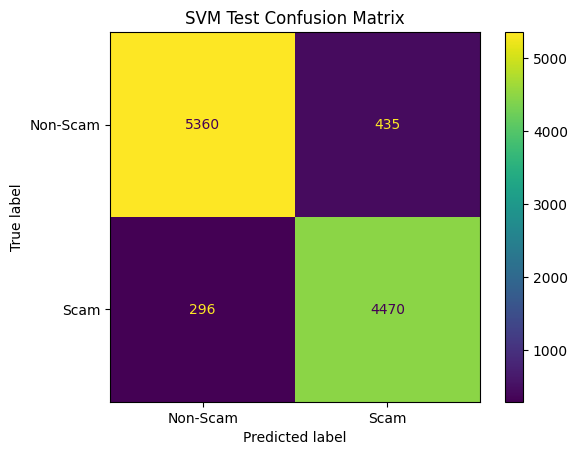


--- RANDOM FOREST TEST RESULTS ---
Test Accuracy: 93.94%
              precision    recall  f1-score   support

    Non-Scam     0.9585    0.9298    0.9439      5795
        Scam     0.9176    0.9511    0.9341      4766

    accuracy                         0.9394     10561
   macro avg     0.9381    0.9404    0.9390     10561
weighted avg     0.9401    0.9394    0.9395     10561



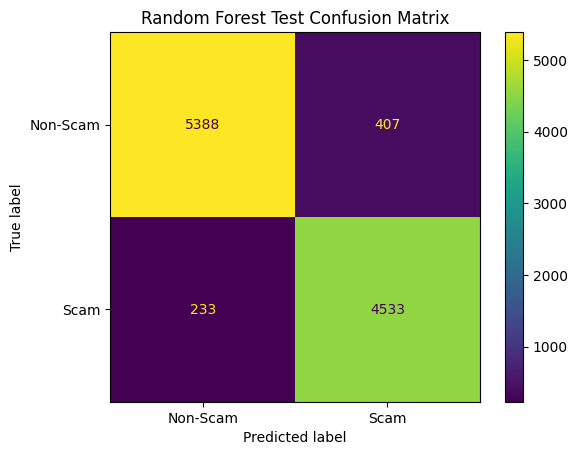

In [16]:
# ═══════════════════════════════════════════════════════════════════════════════
# SVM + RANDOM FOREST RESULTS — VALIDATION SET
# ═══════════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# ═══════════════════════════════════════════════════════════════════════════════
# SVM + RANDOM FOREST RESULTS — TEST SET
# ═══════════════════════════════════════════════════════════════════════════════

X_test_raw = test_data[TEXT_COL].astype(str).reset_index(drop=True)
y_test_ml  = test_data["label"].reset_index(drop=True)


# ─────────────────────────────────────────────
# HELPER: SVM TRANSFORM PIPELINE
# ─────────────────────────────────────────────

def transform_text_svm(X_raw):
    # 1. TF-IDF
    X_tfidf = svm_tfidf.transform(X_raw.astype(str))

    # 2. Variance filter
    X_var = X_tfidf[:, svm_var_mask]

    # 3. Chi-square selection
    X_chi = svm_chi2_selector.transform(X_var)

    # 4. RFE selection
    X_rfe = svm_rfe_selector.transform(X_chi)

    if hasattr(X_rfe, "toarray"):
        X_rfe = X_rfe.toarray()

    return X_rfe


# ─────────────────────────────────────────────
# HELPER: RANDOM FOREST TRANSFORM PIPELINE
# ─────────────────────────────────────────────

def transform_text_rf(X_raw):
    # 1. TF-IDF
    X_tfidf = rf_tfidf.transform(X_raw.astype(str))

    # 2. Variance filter
    X_var = X_tfidf[:, rf_var_mask]

    # 3. Chi-square selection
    X_chi = rf_chi2_selector.transform(X_var)

    # 4. RFE selection
    X_rfe = rf_rfe_selector.transform(X_chi)

    if hasattr(X_rfe, "toarray"):
        X_rfe = X_rfe.toarray()

    return X_rfe


# ─────────────────────────────────────────────
# CONFUSION MATRIX FUNCTION
# ─────────────────────────────────────────────

def plot_cm_like_example(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Non-Scam", "Scam"]
    )

    disp.plot(values_format="d")
    plt.title(title)
    plt.show()


# ═══════════════════════════════════════════════════════════════════════════════
# SVM VALIDATION RESULTS
# ═══════════════════════════════════════════════════════════════════════════════

X_test_svm = transform_text_svm(X_test_raw)

svm_test_probs = best_svm_model.predict_proba(X_test_svm)[:, list(best_svm_model.classes_).index(1)]
svm_test_preds = (svm_test_probs >= 0.5).astype(int)

print("\n--- SVM TEST RESULTS ---")
print(f"Test Accuracy: {accuracy_score(y_test_ml, svm_test_preds) * 100:.2f}%")

print(classification_report(
    y_test_ml,
    svm_test_preds,
    target_names=["Non-Scam", "Scam"],
    digits=4,
    zero_division=0
))

plot_cm_like_example(
    y_test_ml,
    svm_test_preds,
    "SVM Test Confusion Matrix"
)


# ═══════════════════════════════════════════════════════════════════════════════
# RANDOM FOREST TEST RESULTS
# ═══════════════════════════════════════════════════════════════════════════════

X_test_rf = transform_text_rf(X_test_raw)

rf_test_probs = best_rf_model.predict_proba(X_test_rf)[:, list(best_rf_model.classes_).index(1)]
rf_test_preds = (rf_test_probs >= 0.5).astype(int)

print("\n--- RANDOM FOREST TEST RESULTS ---")
print(f"Test Accuracy: {accuracy_score(y_test_ml, rf_test_preds) * 100:.2f}%")

print(
    classification_report(
        y_test_ml,
        rf_test_preds,
        target_names=["Non-Scam", "Scam"],
        digits=4,
        zero_division=0
    )
)

plot_cm_like_example(
    y_test_ml,
    rf_test_preds,
    "Random Forest Test Confusion Matrix"
)

# More Unseen Messages Dataset Testing

| Message | Label |
|---|---|
| Your bank account has been temporarily locked. Verify your identity here immediately: [suspicious link] | Scam |
| Netflix: Your payment failed. Update billing details now to keep your account active: [suspicious link] | Scam |
| Congratulations! You won a RM5000 cash prize. Claim before midnight: [suspicious link] | Scam |
| DHL: Your parcel is on hold due to incorrect address. Confirm delivery details here: [suspicious link] | Scam |
| Your Touch n Go eWallet has been suspended. Login now to reactivate: [suspicious link] | Scam |
| LHDN: You are eligible for a tax refund. Submit your bank details here: [suspicious link] | Scam |
| Security alert: unusual login detected. Enter your OTP to secure your account now. | Scam |
| Maybank: RM1,250 transfer attempt detected. If this was not you, cancel here: [suspicious link] | Scam |
| Shopee: Your account will be deactivated due to suspicious activity. Verify now: [suspicious link] | Scam |
| Final notice: unpaid electricity bill. Pay immediately to avoid disconnection: [suspicious link] | Scam |
| Hi, are you free for lunch tomorrow? | Non-Scam |
| Your parcel has been delivered successfully. Thank you for using our service. | Non-Scam |
| Reminder: Your dentist appointment is scheduled for Friday at 10 AM. | Non-Scam |
| Mom, I reached home safely. I will call you later. | Non-Scam |
| Your meeting with the project team starts at 3 PM today. | Non-Scam |
| Thank you for your payment. Your receipt has been sent to your email. | Non-Scam |
| Hi Sarah, please send me the assignment file when you are done. | Non-Scam |
| Your food delivery rider is arriving soon. | Non-Scam |
| Class is cancelled today due to lecturer emergency. | Non-Scam |
| Can you help me buy bread and eggs on your way home? | Non-Scam |

# Result

## Predict result

In [17]:
def label_confidence_from_scam_prob(scam_prob, threshold=0.5):
    """
    scam_prob = probability of class 1, meaning SCAM.

    If scam_prob >= threshold:
        prediction = SCAM
        confidence = scam_prob

    If scam_prob < threshold:
        prediction = NOT SCAM
        confidence = 1 - scam_prob
    """

    if scam_prob >= threshold:
        label = "SCAM"
        confidence = scam_prob
    else:
        label = "NOT SCAM"
        confidence = 1 - scam_prob

    return label, scam_prob, confidence



In [22]:
# ═══════════════════════════════════════════════════════════════════════════════
# PREDICT NEW TEXT — SVM + RANDOM FOREST (ML VERSION)
# ═══════════════════════════════════════════════════════════════════════════════

import pandas as pd

# ─────────────────────────────────────────────
# SAFETY FUNCTION (handles probability + fallback)
# ─────────────────────────────────────────────

def safe_predict_proba(model, X):
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X)
        scam_index = list(model.classes_).index(1)
        return probs[0][scam_index]
    else:
        return float(model.predict(X)[0])


# ─────────────────────────────────────────────
# LABEL FUNCTION
# ─────────────────────────────────────────────

def label_confidence_from_scam_prob(scam_prob, threshold=0.5):
    label = "SCAM" if scam_prob >= threshold else "NOT SCAM"

    if label == "SCAM":
        confidence = scam_prob
    else:
        confidence = 1 - scam_prob

    return label, scam_prob, confidence


# ─────────────────────────────────────────────
# TEST TEXTS (IMPORTANT: MUST DEFINE)
# ─────────────────────────────────────────────

texts = [
    ("Your bank account has been temporarily locked. Verify your identity here immediately: [suspicious link]", "Scam"),
    ("Netflix: Your payment failed. Update billing details now to keep your account active: [suspicious link]", "Scam"),
    ("Congratulations! You won a RM5000 cash prize. Claim before midnight: [suspicious link]", "Scam"),
    ("DHL: Your parcel is on hold due to incorrect address. Confirm delivery details here: [suspicious link]", "Scam"),
    ("Your Touch n Go eWallet has been suspended. Login now to reactivate: [suspicious link]", "Scam"),
    ("LHDN: You are eligible for a tax refund. Submit your bank details here: [suspicious link]", "Scam"),
    ("Security alert: unusual login detected. Enter your OTP to secure your account now.", "Scam"),
    ("Maybank: RM1,250 transfer attempt detected. If this was not you, cancel here: [suspicious link]", "Scam"),
    ("Shopee: Your account will be deactivated due to suspicious activity. Verify now: [suspicious link]", "Scam"),
    ("Final notice: unpaid electricity bill. Pay immediately to avoid disconnection: [suspicious link]", "Scam"),

    ("Hi, are you free for lunch tomorrow?", "Non-Scam"),
    ("Your parcel has been delivered successfully. Thank you for using our service.", "Non-Scam"),
    ("Reminder: Your dentist appointment is scheduled for Friday at 10 AM.", "Non-Scam"),
    ("Mom, I reached home safely. I will call you later.", "Non-Scam"),
    ("Your meeting with the project team starts at 3 PM today.", "Non-Scam"),
    ("Thank you for your payment. Your receipt has been sent to your email.", "Non-Scam"),
    ("Hi Sarah, please send me the assignment file when you are done.", "Non-Scam"),
    ("Your food delivery rider is arriving soon.", "Non-Scam"),
    ("Class is cancelled today due to lecturer emergency.", "Non-Scam"),
    ("Can you help me buy bread and eggs on your way home?", "Non-Scam"),
]


# ─────────────────────────────────────────────
# SVM PREDICTION FUNCTION
# ─────────────────────────────────────────────

def predict_text_svm(raw_text):

    X = svm_tfidf.transform([raw_text])
    X = X[:, svm_var_mask]
    X = svm_chi2_selector.transform(X)
    X = svm_rfe_selector.transform(X)

    if hasattr(X, "toarray"):
        X = X.toarray()

    scam_prob = safe_predict_proba(best_svm_model, X)

    return label_confidence_from_scam_prob(float(scam_prob))


# ─────────────────────────────────────────────
# RANDOM FOREST PREDICTION FUNCTION
# ─────────────────────────────────────────────

def predict_text_rf(raw_text):

    X = rf_tfidf.transform([raw_text])
    X = X[:, rf_var_mask]
    X = rf_chi2_selector.transform(X)
    X = rf_rfe_selector.transform(X)

    if hasattr(X, "toarray"):
        X = X.toarray()

    scam_prob = safe_predict_proba(best_rf_model, X)

    return label_confidence_from_scam_prob(float(scam_prob))


# ─────────────────────────────────────────────
# RUN PREDICTIONS
# ─────────────────────────────────────────────

rows = []

for msg, true_label in texts:

    svm_label, svm_prob, svm_conf = predict_text_svm(msg)
    rf_label, rf_prob, rf_conf = predict_text_rf(msg)

    rows.append({
        "Message": msg,
        "True Label": true_label,

        "SVM Prediction": svm_label,
        "SVM Scam Probability": round(svm_prob, 4),
        "SVM Confidence": round(svm_conf, 4),

        "RF Prediction": rf_label,
        "RF Scam Probability": round(rf_prob, 4),
        "RF Confidence": round(rf_conf, 4),
    })


results_ml_df = pd.DataFrame(rows)


# ─────────────────────────────────────────────
# COLOR FUNCTION (LIKE YOUR DL TABLE)
# ─────────────────────────────────────────────

def color_prediction(val):
    if val == "SCAM":
        return "background-color: #FFCCCC; color: #7B0000"
    elif val == "NOT SCAM":
        return "background-color: #CCFFCC; color: #004D00"
    return ""


# ─────────────────────────────────────────────
# DISPLAY TABLE (LIKE YOUR CNN/MLP STYLE)
# ─────────────────────────────────────────────

display(
    results_ml_df.style
    .map(color_prediction, subset=["SVM Prediction", "RF Prediction"])
    .format({
        "SVM Scam Probability": "{:.4f}",
        "SVM Confidence": "{:.4f}",
        "RF Scam Probability": "{:.4f}",
        "RF Confidence": "{:.4f}",
    })
    .set_table_styles([
        {"selector": "th", "props": [("background-color", "#f0f0f0"), ("font-weight", "bold"), ("text-align", "center")]},
        {"selector": "td", "props": [("text-align", "center"), ("vertical-align", "middle")]},
        {"selector": "td:first-child", "props": [("text-align", "left"), ("max-width", "350px"), ("white-space", "normal")]},
    ])
    .set_caption("Prediction Results — SVM vs Random Forest (ML Models)")
)

,Message,True Label,SVM Prediction,SVM Scam Probability,SVM Confidence,RF Prediction,RF Scam Probability,RF Confidence
0,Your bank account has been temporarily locked. Verify your identity here immediately: [suspicious link],Scam,SCAM,1.0000,1.0000,SCAM,0.7660,0.7660
1,Netflix: Your payment failed. Update billing details now to keep your account active: [suspicious link],Scam,SCAM,0.9892,0.9892,SCAM,0.7660,0.7660
2,Congratulations! You won a RM5000 cash prize. Claim before midnight: [suspicious link],Scam,SCAM,0.9482,0.9482,SCAM,0.7637,0.7637
3,DHL: Your parcel is on hold due to incorrect address. Confirm delivery details here: [suspicious link],Scam,SCAM,0.8877,0.8877,SCAM,0.7641,0.7641
4,Your Touch n Go eWallet has been suspended. Login now to reactivate: [suspicious link],Scam,SCAM,0.8877,0.8877,SCAM,0.7637,0.7637
5,LHDN: You are eligible for a tax refund. Submit your bank details here: [suspicious link],Scam,SCAM,0.9641,0.9641,SCAM,0.7637,0.7637
6,Security alert: unusual login detected. Enter your OTP to secure your account now.,Scam,SCAM,1.0000,1.0000,SCAM,0.7632,0.7632
7,"Maybank: RM1,250 transfer attempt detected. If this was not you, cancel here: [suspicious link]",Scam,SCAM,0.8877,0.8877,SCAM,0.7643,0.7643
8,Shopee: Your account will be deactivated due to suspicious activity. Verify now: [suspicious link],Scam,SCAM,0.9963,0.9963,SCAM,0.7660,0.7660
9,Final notice: unpaid electricity bill. Pay immediately to avoid disconnection: [suspicious link],Scam,SCAM,0.6428,0.6428,SCAM,0.7637,0.7637


# Export FINAL model files for Scam Shield
Run the next cell after the final model training cells are complete.


In [31]:
# EXPORT ML FINAL MODELS FOR SCAM SHIELD

from pathlib import Path
import joblib

def find_models_dir():
    candidates = [
        Path.cwd() / "models",
        Path.cwd().parent / "models",
        Path("../models").resolve(),
        Path("models").resolve(),
    ]
    for c in candidates:
        if c.exists() and c.is_dir():
            return c
    c = Path("models").resolve()
    c.mkdir(parents=True, exist_ok=True)
    return c

EXPORT_DIR = find_models_dir()
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

required_names = [
    "svm_tfidf", "svm_var_mask", "svm_chi2_selector", "svm_rfe_selector", "best_svm_model",
    "rf_tfidf", "rf_var_mask", "rf_chi2_selector", "rf_rfe_selector", "best_rf_model",
]
missing = [name for name in required_names if name not in globals()]
if missing:
    raise NameError(
        "These trained ML objects are missing. Run the ML_FINAL notebook until SVM and RF training are complete first: "
        + ", ".join(missing)
    )

svm_bundle = {
    "artifact_version": "ML_FINAL",
    "model_family": "SVM",
    "preprocess": "clean_message",
    "threshold": 0.5,
    "vectorizer": svm_tfidf,
    "var_mask": svm_var_mask,
    "chi2_selector": svm_chi2_selector,
    "rfe_selector": svm_rfe_selector,
    "model": best_svm_model,
    "classes": list(map(int, best_svm_model.classes_)),
}

rf_bundle = {
    "artifact_version": "ML_FINAL",
    "model_family": "RandomForest",
    "preprocess": "clean_message",
    "threshold": 0.5,
    "vectorizer": rf_tfidf,
    "var_mask": rf_var_mask,
    "chi2_selector": rf_chi2_selector,
    "rfe_selector": rf_rfe_selector,
    "model": best_rf_model,
    "classes": list(map(int, best_rf_model.classes_)),
}

joblib.dump(svm_bundle, EXPORT_DIR / "ml_final_svm.joblib")
joblib.dump(rf_bundle, EXPORT_DIR / "ml_final_rf.joblib")

print("ML FINAL models exported successfully to:", EXPORT_DIR)
print("Created:")
print(" -", EXPORT_DIR / "ml_final_svm.joblib")
print(" -", EXPORT_DIR / "ml_final_rf.joblib")


ML FINAL models exported successfully to: C:\Users\fanch\Desktop\FYP\test on new dataset\test - 10000 dataset\models
Created:
 - C:\Users\fanch\Desktop\FYP\test on new dataset\test - 10000 dataset\models\ml_final_svm.joblib
 - C:\Users\fanch\Desktop\FYP\test on new dataset\test - 10000 dataset\models\ml_final_rf.joblib
